In [24]:
# - Pandas
# - Numpy
# - Matplotlib
# - Seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [25]:
# First lets load the data into a dataframe
df = pd.read_csv('./insurance.csv')

# Create a new column 'insurance_cost_binary'
# 0 if insurance_cost is less than or equal to the median insurance cost
# 1 otherwise
median_insurance_cost = df['insurance_cost'].median()
df['insurance_cost_binary'] = (df['insurance_cost'] > median_insurance_cost).astype(int)
# remove the original insurance_cost column
df.drop(columns=['insurance_cost'], inplace=True)

df.head()


,age,gender,bmi,children,smoker,region,insurance_cost_binary
0,18,male,33.770,1,no,southeast,0
1,18,male,34.100,0,no,southeast,0
2,18,female,26.315,0,no,northeast,0
3,18,female,38.665,2,no,northeast,0
4,18,female,35.625,0,no,northeast,0


In [26]:
# print the data types of the columns
print("Data types of the columns:") 
print(df.dtypes)


# Display dataset shape
print('\nDataset shape:', df.shape)

Data types of the columns:
age                        int64
gender                       str
bmi                      float64
children                   int64
smoker                       str
region                       str
insurance_cost_binary      int64
dtype: object

Dataset shape: (1338, 7)


In [27]:
# Lets look at the summary statistics for numerical attributes

print("\nSummary statistics for numeric attributes:\n")

df.describe()


Summary statistics for numeric attributes:



,age,bmi,children,insurance_cost_binary
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,0.500000
std,14.049960,6.098187,1.205493,0.500187
min,18.000000,15.960000,0.000000,0.000000
25%,27.000000,26.296250,0.000000,0.000000
50%,39.000000,30.400000,1.000000,0.500000
75%,51.000000,34.693750,2.000000,1.000000
max,64.000000,53.130000,5.000000,1.000000


In [28]:
# Frequency counts for categorical attributes
categorical_attributes  = df.select_dtypes(include=['str']).columns

print("\nCategorical attributes:\n")
print(list(categorical_attributes))

print("\nFrequency counts for categorical attributes:\n")

for column in categorical_attributes: 
    print("\n")
    print(df[column].value_counts(dropna=False))
    print("--------------------------------")


Categorical attributes:

['gender', 'smoker', 'region']

Frequency counts for categorical attributes:



gender
male      676
female    662
Name: count, dtype: int64
--------------------------------


smoker
no     1064
yes     274
Name: count, dtype: int64
--------------------------------


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
--------------------------------


In [29]:
# Lets see if there are any missing values
df.isna().sum()

age                      0
gender                   0
bmi                      0
children                 0
smoker                   0
region                   0
insurance_cost_binary    0
dtype: int64

                            age       bmi  children  insurance_cost_binary
age                    1.000000  0.109272  0.042469               0.512617
bmi                    0.109272  1.000000  0.012759               0.089896
children               0.042469  0.012759  1.000000               0.019227
insurance_cost_binary  0.512617  0.089896  0.019227               1.000000


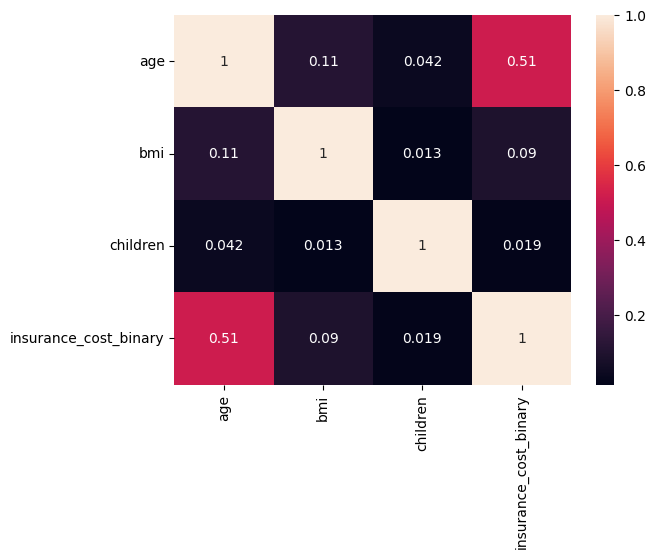

In [30]:
# correlation matrix
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)
print(corr_matrix)

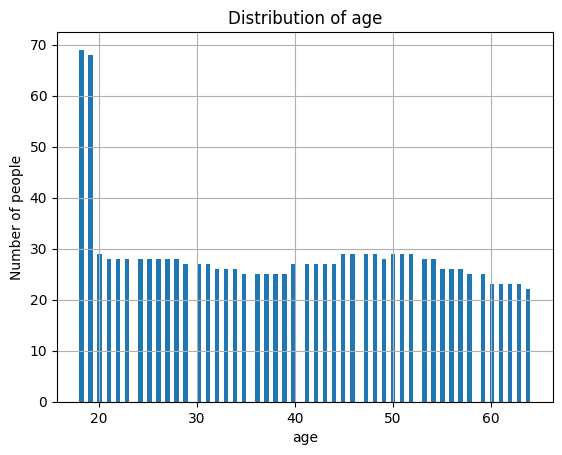

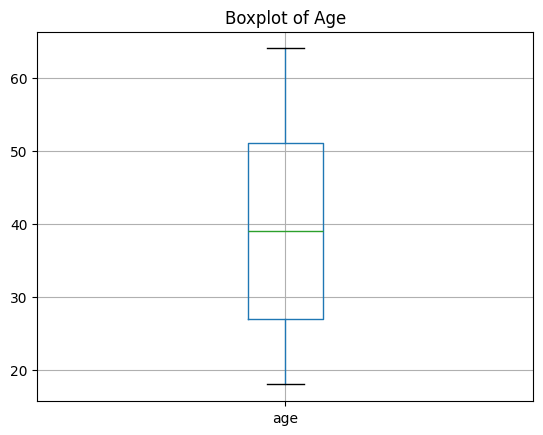

In [38]:
# lets see the distribution of balance
df['age'].hist(bins=100)
plt.xlabel('age')
plt.ylabel('Number of people')
plt.title('Distribution of age')
plt.show()

df.boxplot(column='age')
plt.title('Boxplot of Age')
plt.show()

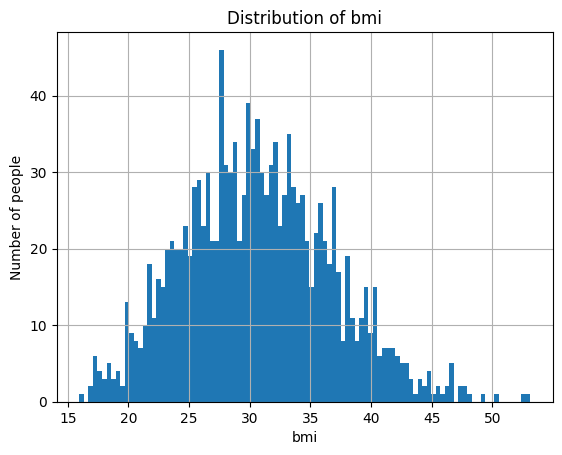

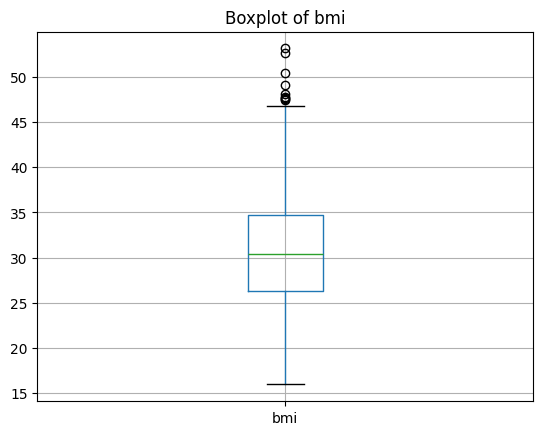

In [39]:
# lets see the distribution of balance
df['bmi'].hist(bins=100)
plt.xlabel('bmi')
plt.ylabel('Number of people')
plt.title('Distribution of bmi')
plt.show()

df.boxplot(column='bmi')
plt.title('Boxplot of bmi')
plt.show()

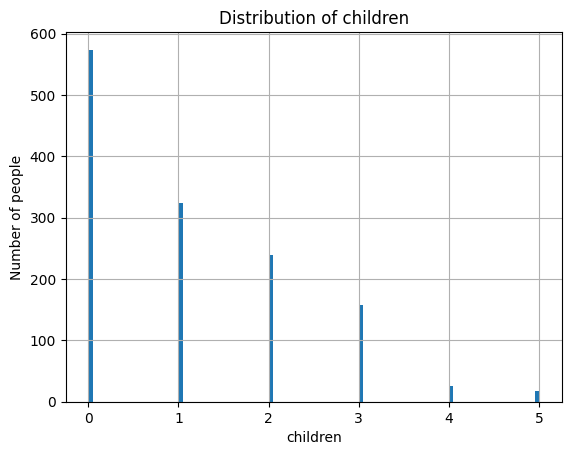

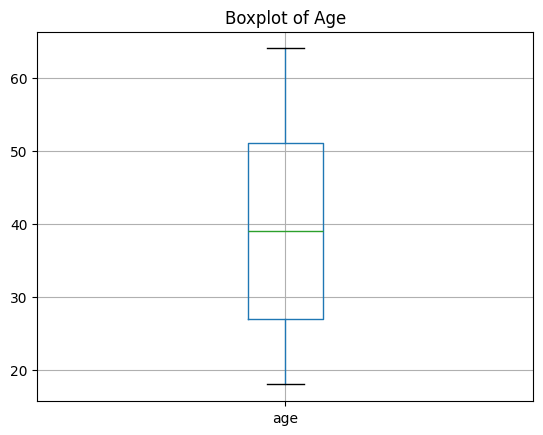

In [40]:
# lets see the distribution of balance
df['children'].hist(bins=100)
plt.xlabel('children')
plt.ylabel('Number of people')
plt.title('Distribution of children')
plt.show()

df.boxplot(column='age')
plt.title('Boxplot of Age')
plt.show()

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region',
       'insurance_cost_binary'],
      dtype='str')


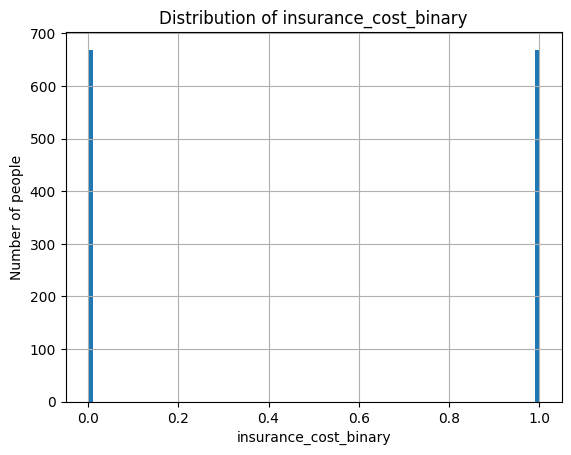

In [37]:
print(df.columns)
# lets see the distribution of insurance_cost_binary
df['insurance_cost_binary'].hist(bins=100)
plt.xlabel('insurance_cost_binary')
plt.ylabel('Number of people')
plt.title('Distribution of insurance_cost_binary')
plt.show()